# AI-powered Cloud Masking
- Machine learning was used more specifically `Random Forest` to detect clouds using binary masks

## Setup Environment  

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

from utils import image_mask_to_array, image_mask_to_df, plot_image_mask_pred, build_training_dataframe_dask, read_and_plot, save_model_and_print_params
from loading import load_full_dataset, load_model
from evaluation import evaluate_dice_score
from const import IMAGES_PATH, MASKS_PATH

## Loading Dataset and Splitting

In [ ]:
images, masks = load_full_dataset(
    IMAGES_PATH, MASKS_PATH
)
images.shape, masks.shape

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

In [ ]:
df_train = build_training_dataframe_dask(x_train, y_train)
df_train.shape

## Exploratory Data Analysis 

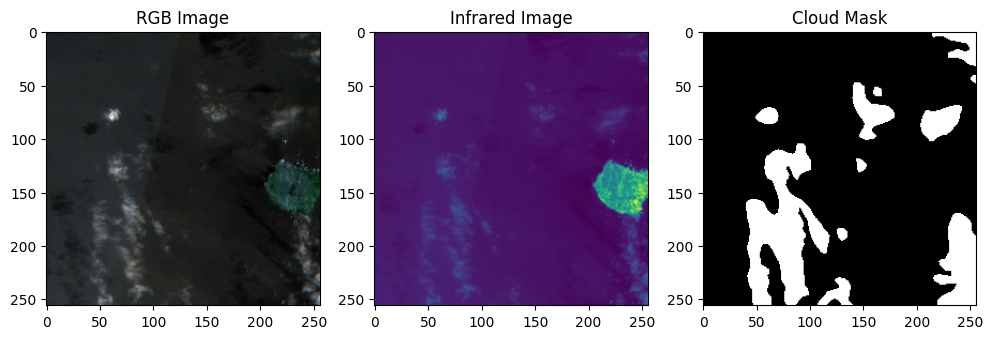

array([0, 1], dtype=uint8)

In [ ]:
image_path, mask_path = read_and_plot(104666)

image, mask = load_image_and_mask(image_path, mask_path)
image = per_band_minmax(image)

plot_image_and_mask(image, mask)
np.unique(mask)

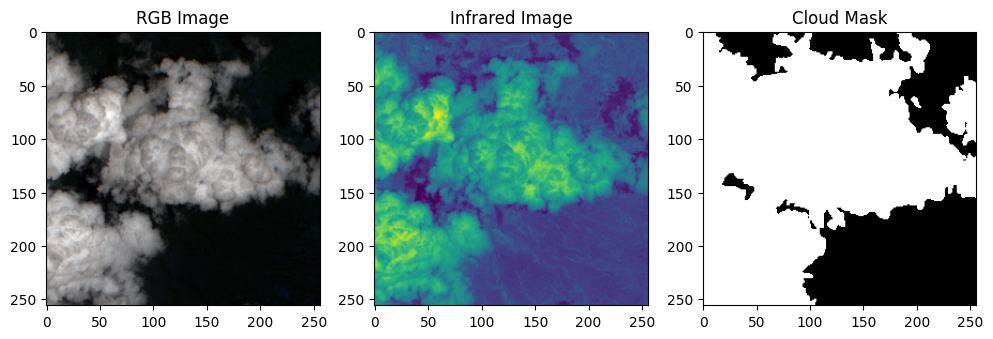

array([0, 1], dtype=uint8)

In [ ]:
image_path, mask_path = read_and_plot(119627)

image, mask = load_image_and_mask(image_path, mask_path)
image = per_band_minmax(image)

plot_image_and_mask(image, mask)
np.unique(mask)

In [12]:
image_mask_to_df(x_train[0], y_train[0]).shape

(65536, 7)

In [14]:
# correlation_matrix_pca = df_train.corr()

# # Plot the correlation matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation_matrix_pca, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Correlation Matrix of PCA-transformed Features')
# plt.show()

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78643200 entries, 0 to 65535
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   r            float32
 1   g            float32
 2   b            float32
 3   infrared     float32
 4   ndsi         float32
 5   cloud_index  float32
 6   class        bool   
dtypes: bool(1), float32(6)
memory usage: 2.4 GB


class
True     50929432
False    27713768
Name: count, dtype: int64


<Axes: xlabel='class'>

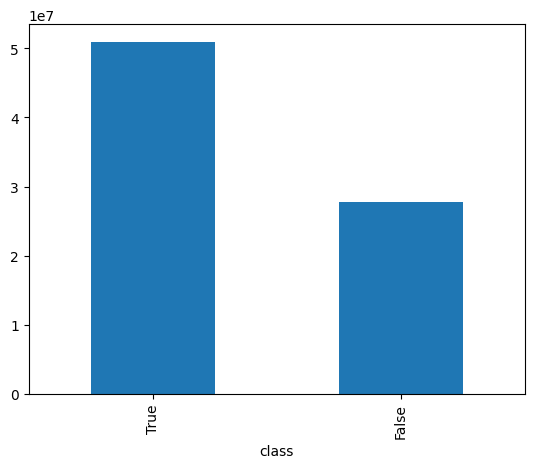

In [16]:
print(df_train["class"].value_counts())
df_train["class"].value_counts().plot(kind="bar")

## Building Model

In [17]:
X = df_train.drop(columns=["class"])
y = df_train["class"]

In [18]:
# X = x_train.reshape(-1, 4).astype('float32')  # Flatten the images to (n_samples, 4)
# y =  y_train.reshape(-1).astype('float32')

In [19]:
pca = PCA(n_components=X.shape[1])
model = make_pipeline(
    pca,
    RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1  # number of trees
    ),
)
X.shape[1]

6

In [20]:
model.fit(X, y)

Pipeline(steps=[('pca', PCA(n_components=6)),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=15, n_jobs=-1,
                                        random_state=42))])

## Exploring Final Model

In [23]:
save_model_and_print_params(model)

Model saved to random_forest_model.pkl

Model Parameters:

Parameters for pca:
  copy: True
  iterated_power: auto
  n_components: 6
  n_oversamples: 10
  power_iteration_normalizer: auto
  random_state: None
  svd_solver: auto
  tol: 0.0
  whiten: False

Parameters for randomforestclassifier:
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: None
  criterion: gini
  max_depth: 15
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 100
  n_jobs: -1
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False


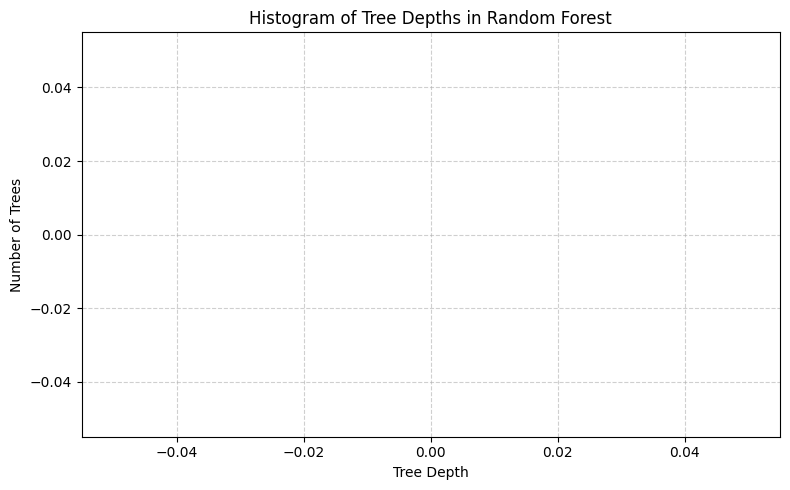

In [24]:
# Access trained RandomForestClassifier from pipeline
rf = model.named_steps["randomforestclassifier"]

# Get all tree depths
depths = [estimator.tree_.max_depth for estimator in rf.estimators_]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(
    depths, bins=range(min(depths), max(depths) + 1), color="skyblue", edgecolor="black"
)
plt.title("Histogram of Tree Depths in Random Forest")
plt.xlabel("Tree Depth")
plt.ylabel("Number of Trees")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Feature Importance')

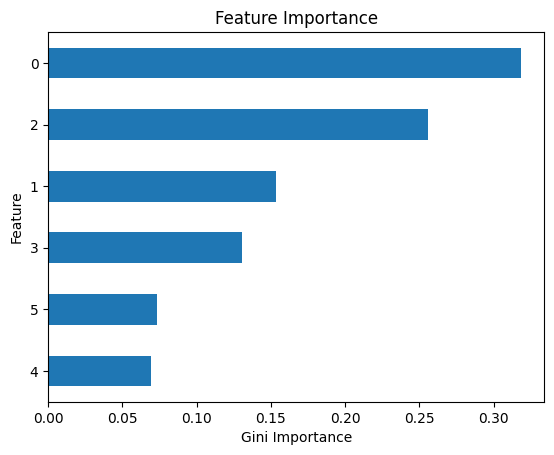

In [25]:
# Extract importances from model
importances = model.named_steps["randomforestclassifier"].feature_importances_
# Create a series with feature names and importances
feat_imp = pd.Series(importances)
# Plot 10 most important features
feat_imp.sort_values().tail(10).plot(kind="barh")
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

In [26]:
# Assuming pca is your fitted PCA object
pca_components = pd.DataFrame(pca.components_, columns=X.columns)

print(pca_components.head())

              r             g             b      infrared      ndsi  \
0  1.855734e-07  2.662425e-07  1.458018e-07 -5.170249e-08  0.000007   
1  4.624666e-01  4.757665e-01  4.830532e-01  5.663118e-01  0.075640   
2  1.438259e-01  9.349224e-02  9.066732e-02 -3.933665e-01  0.898674   
3 -6.058205e-01 -9.604631e-02  7.843161e-01 -9.192752e-02 -0.012419   
4 -5.128443e-01  8.046876e-01 -2.979464e-01 -6.499394e-03  0.025577   

    cloud_index  
0  1.000000e+00  
1 -7.968318e-07  
2 -6.538750e-06  
3  1.080734e-07  
4 -2.596435e-07  


In [27]:
importance_scores = pca_components.abs().sum(axis=0)
print(importance_scores.sort_values())

cloud_index    1.000011
ndsi           1.443427
infrared       1.776479
g              1.798867
b              1.889468
r              2.092940
dtype: float32


## Evaluation 

In [53]:
model = load_model("./random_forest_model8852.pkl")

Model loaded from ./random_forest_model8852.pkl


In [54]:
score = evaluate_dice_score(model, image_mask_to_array(images), masks)
print(f"Accuracy: {score:.4f}")

c:\Users\mroan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\mroan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\mroan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\mroan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\mroan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature na

Accuracy: 0.8782


c:\Users\mroan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


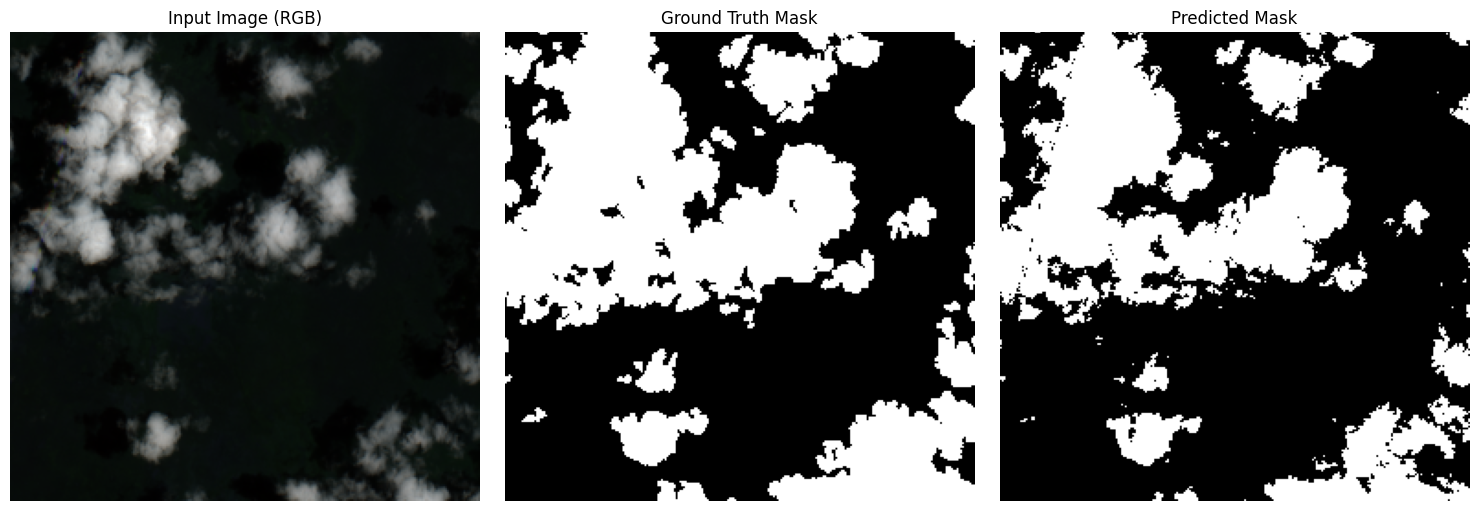

[0 1]


In [61]:
plot_image_mask_pred(model, image_mask_to_array(x_test), y_test, 30)